In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import yaml

# Generating drone movement pattern

In [2]:
def gen_lawnmower_pattern(
    size: tuple[int, int],
    velocity: float,
    t_acq: int,
    num_passes: int = 10,
    start: tuple[float, float] = (0., 0.)
):

    # build waypoionts based on provided size
    y_levels = np.linspace(start[1], size[1], num_passes)
    y_waypoints = np.array(list(zip(y_levels, y_levels))).flatten()

    x_waypoints = np.array([
        start[0] if n==1 or ((n-2)//2)%2 else size[0]
        for n in range(1, num_passes*2+1)
    ])

    # generate array of sampling points based on t_acq and velocity
    step = velocity * t_acq
    deltas = np.diff(np.c_[x_waypoints, y_waypoints], axis=0)
    distances = np.linalg.norm(deltas, axis=1)
    s = np.insert(np.cumsum(distances), 0, 0)
    s_samples = np.arange(0, s[-1], step)
    s_samples = np.append(s_samples, s[-1])

    # interp. original waypoints with sampling points
    x = np.interp(s_samples, s, x_waypoints)
    y = np.interp(s_samples, s, y_waypoints)
    path = np.c_[x, y]

    return path, s_samples

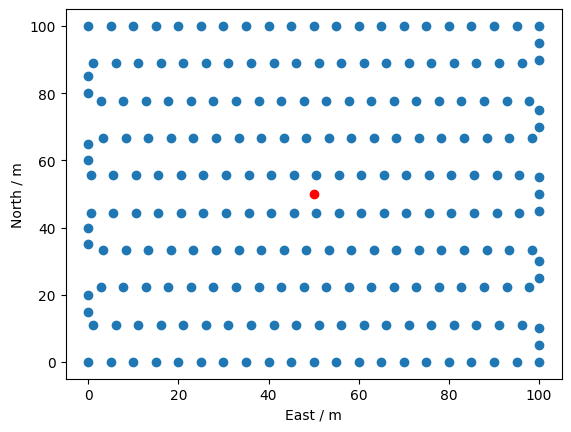

In [3]:
path, s = gen_lawnmower_pattern(
    size = (100, 100),
    velocity = 5,
    t_acq = 1
)

plt.scatter(path[:,0], path[:,1])
plt.plot(50,50,'ro') 
plt.xlabel("East / m")
plt.ylabel("North / m")
plt.savefig("figs/drone-scenario.png")

In [73]:
pd.DataFrame({'East': path[:,0], 'North': path[:,1], 'dist': s}).to_csv("coords.csv", index=False)

## Adding background counts

In [57]:
BKG_CPS = 50
SRC_ACT = 50

In [58]:
with open('drone_test.yml', "r") as file:
    conf = yaml.safe_load(file)

conf['options']['bkg_cps'] = BKG_CPS
conf['name'] = f'drone_test_{BKG_CPS}_cps'
conf['sources']['s1']['activity_MBq'] = SRC_ACT

with open('drone_test.yml', "w") as file:
    yaml.dump(conf, file, sort_keys=False)

In [59]:
! cd pgrad_output && pgrad --config ../drone_test.yml --save

2026-05-16 16:35:09,169 - INFO: Landscape built successfully: drone_test_50_cps
<class 'numpy.bool'>
2026-05-16 16:35:09,185 - INFO: Simulation output saved to drone_test_50_cps_result_20260516_1635!
2026-05-16 16:35:09,538 - WARNING: Path is above the slice height z.It will not show on the plot.


# PG-RAD output from drone

Change the folder name / file name based on PG-RAD output above.

In [60]:
FOLDER_NAME = 'pgrad_output/drone_test_50_cps_result_20260516_1635'

In [61]:
df = pd.read_csv(f"{FOLDER_NAME}/1_src_{BKG_CPS}_cps_bkg_{SRC_ACT}MBq_26m_50_50.csv")

In [62]:
df

,East,North,ROI_P,ROI_BR,Dist
0,5.0,0.0,44.505341,50.018636,5.000000
1,10.0,0.0,48.121582,50.018636,10.000000
2,15.0,0.0,44.403286,50.018636,15.000000
3,20.0,0.0,47.979275,50.018636,20.000000
4,25.0,0.0,43.231782,50.018636,25.000000
...,...,...,...,...,...
215,20.0,100.0,43.724383,50.018636,1063.230435
216,15.0,100.0,43.742903,50.018636,1068.230435
217,10.0,100.0,46.225911,50.018636,1073.230435
218,5.0,100.0,46.101916,50.018636,1078.230435


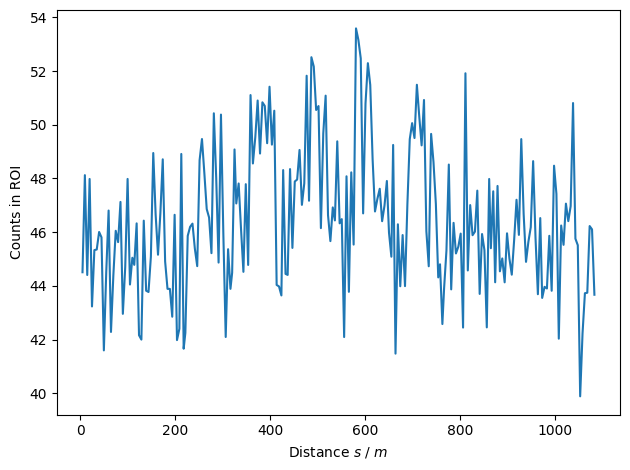

In [63]:
plt.plot(df['Dist'], df['ROI_P'])
plt.xlabel("Distance $s$ / $m$")
plt.ylabel("Counts in ROI")
plt.tight_layout()
plt.savefig(f"figs/drone-counts-{BKG_CPS}bkgcps-{SRC_ACT}MBq.png")

Let's see how it looks in space instead.

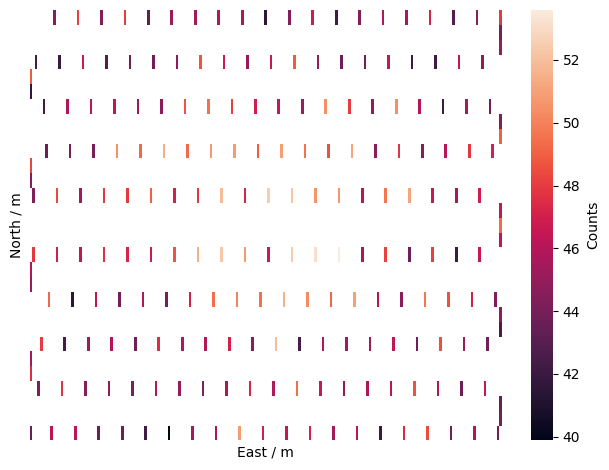

In [64]:
heatmap_data = df.pivot(index='North', columns='East', values='ROI_P')

ax = sns.heatmap(
    heatmap_data,
    xticklabels=False,
    yticklabels=False,
    cbar_kws={'label': 'Counts'}
)

# plt.title("Spatial count acquisitions")
plt.xlabel("East / m")
plt.ylabel("North / m")
plt.tight_layout()
plt.savefig(f"figs/drone-counts-spatial-{BKG_CPS}bkgcps-{SRC_ACT}MBq.png")

## Interpolated

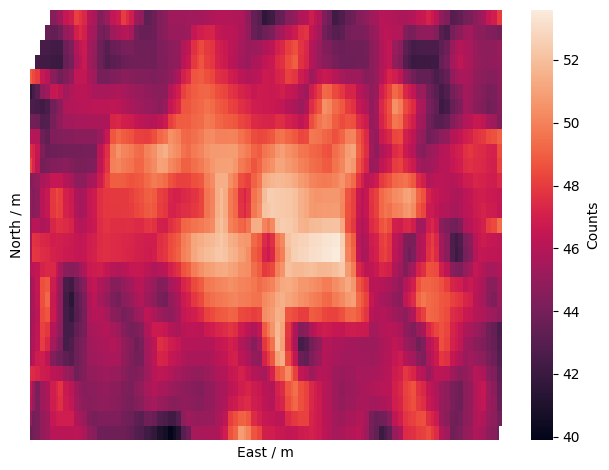

In [65]:
from scipy.interpolate import griddata

east_vals = heatmap_data.columns.values
north_vals = heatmap_data.index.values

# create grid for interpolation
east_grid, north_grid = np.meshgrid(east_vals, north_vals)
points = np.column_stack((df['East'], df['North']))
values = df['ROI_P'].values

grid_z = griddata(points, values, (east_grid, north_grid), method='linear')

interpolated_data = pd.DataFrame(
    grid_z,
    index=north_vals,
    columns=east_vals
)

sns.heatmap(
    interpolated_data,
    xticklabels=False,
    yticklabels=False,
    cbar_kws={'label': 'Counts'},
)
plt.xlabel("East / m")
plt.ylabel("North / m")
# plt.title("Interpolated spatial counts")
plt.tight_layout()
plt.savefig(f"figs/drone-counts-spatial-interp-{BKG_CPS}bkgcps-{SRC_ACT}MBq.png")